# Population loss dynamics

### $L(t)$ and $q(t)$ dynamics at fixed $\beta$ and different vocabulary sizes $d$

In [3]:
from POPevo import evoloss_beta_fixed

alphas = [0.5, 1.0, 1.5]
ds = [int(1e2), int(1e3), int(1e4), int(1e5), int(1e6)]
method = 'flip'

#----Evo and data creation----
filepath = evoloss_beta_fixed(alphas, ds, beta=0.4, n_passes = 10, t_start=1e-3, t_stop=1e5, nice_plots=True, method=method)



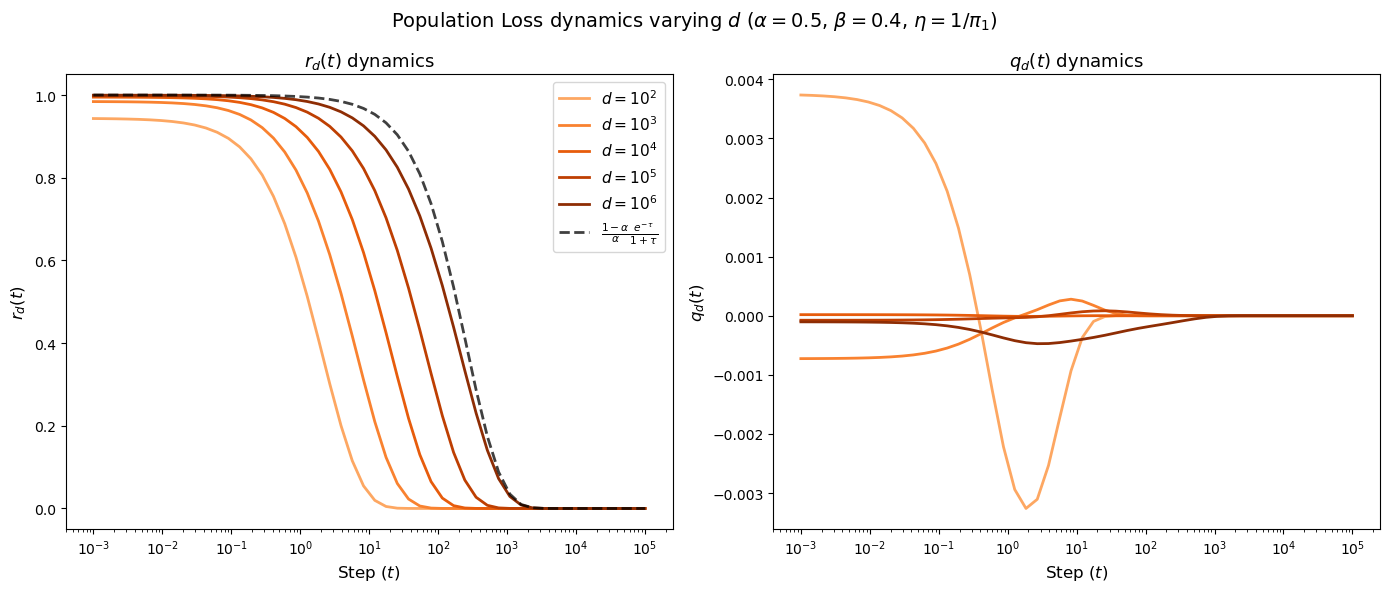

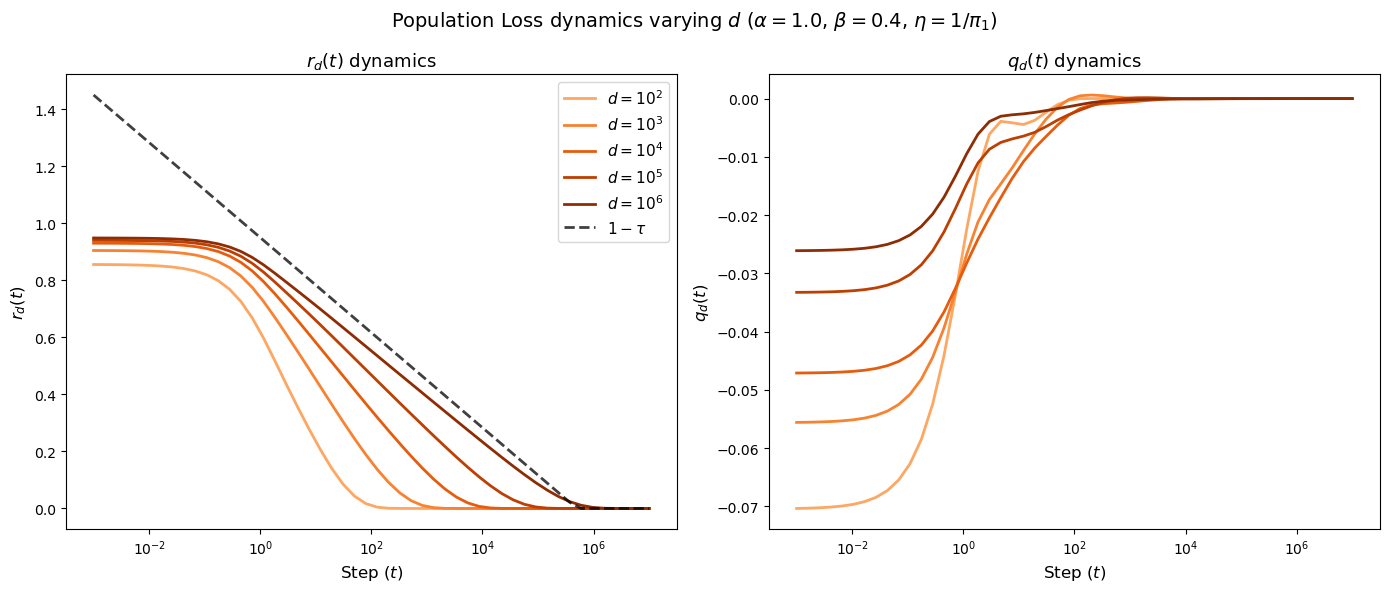

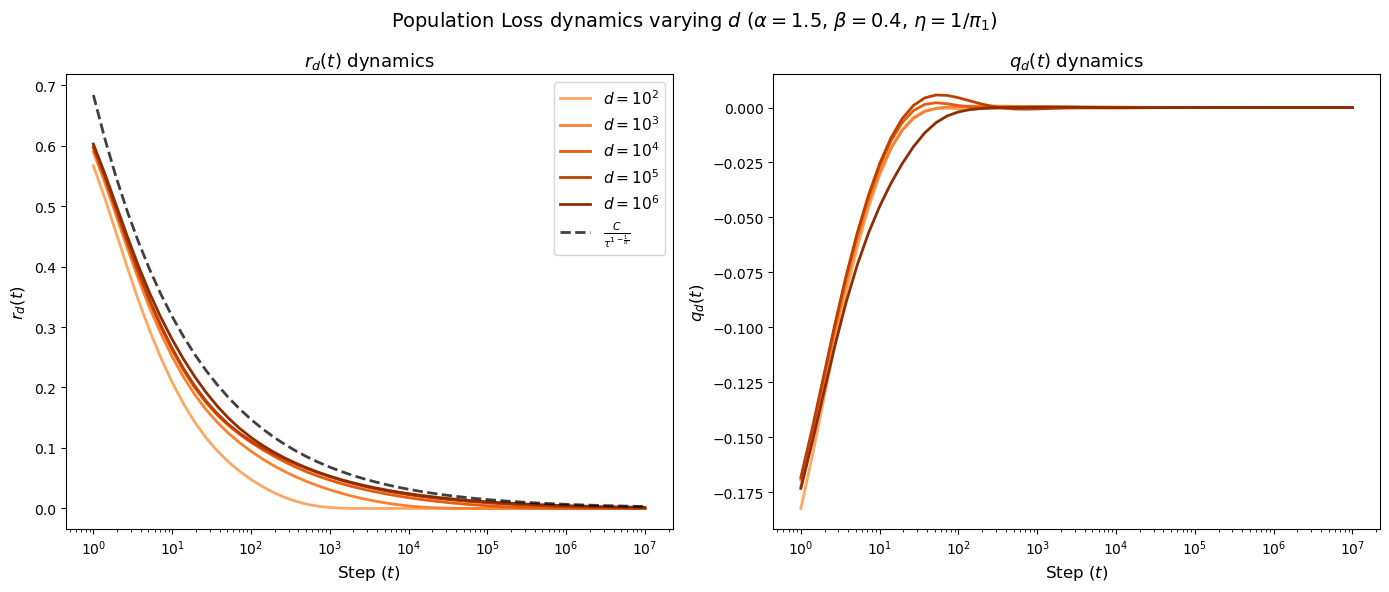

In [5]:
from POPplots import plot_beta_fixed
filepath='/home/lucadriu/Desktop/uni/Tesi/Final/experiments/all/population/data/evo_fixed_beta_flip.pkl'
#----Plot--------
plot_beta_fixed(filepath)

### $L(t)$ and $q(t)$ dynamics at fixed vocabulary size $d$ and different $\beta$

In [ ]:
from POPevo import evoloss_d_fixed

alphas = [0.5, 1.0, 1.5]
betas = [0.00, 0.2, 0.40, 0.6, 0.8]
d = 10000
method = 'greedy'

#----Evo and data creation----
filepath = evoloss_d_fixed(alphas, d, betas, n_passes = 10, method=method)

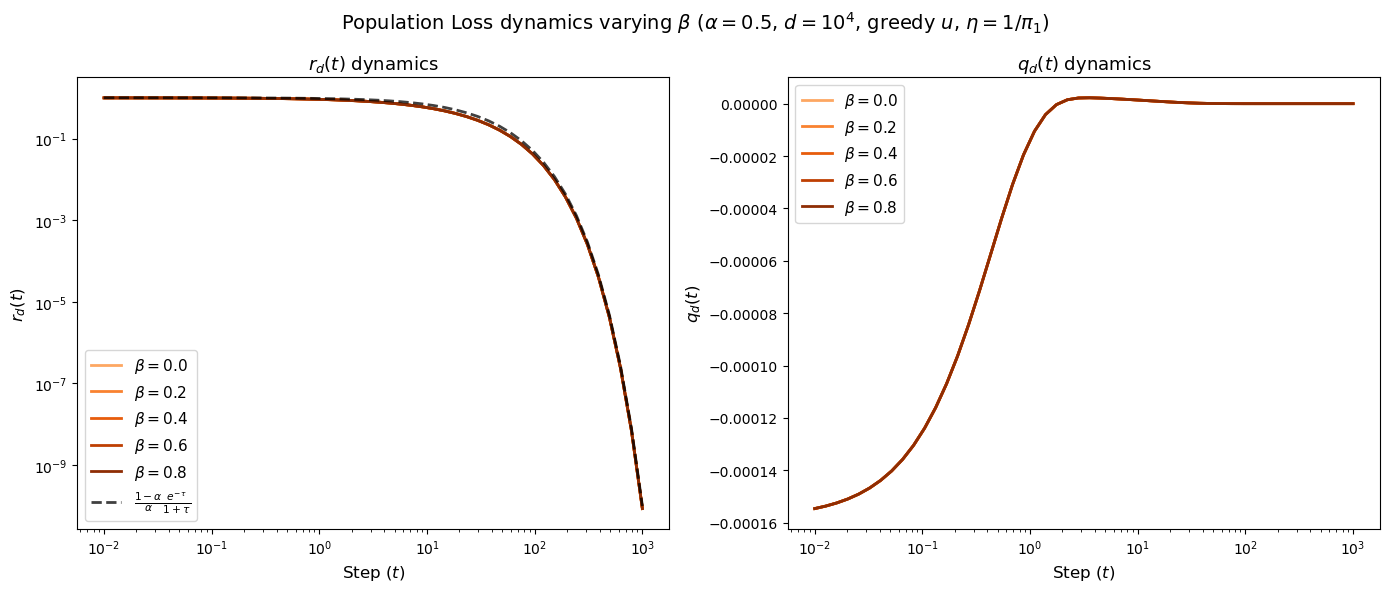

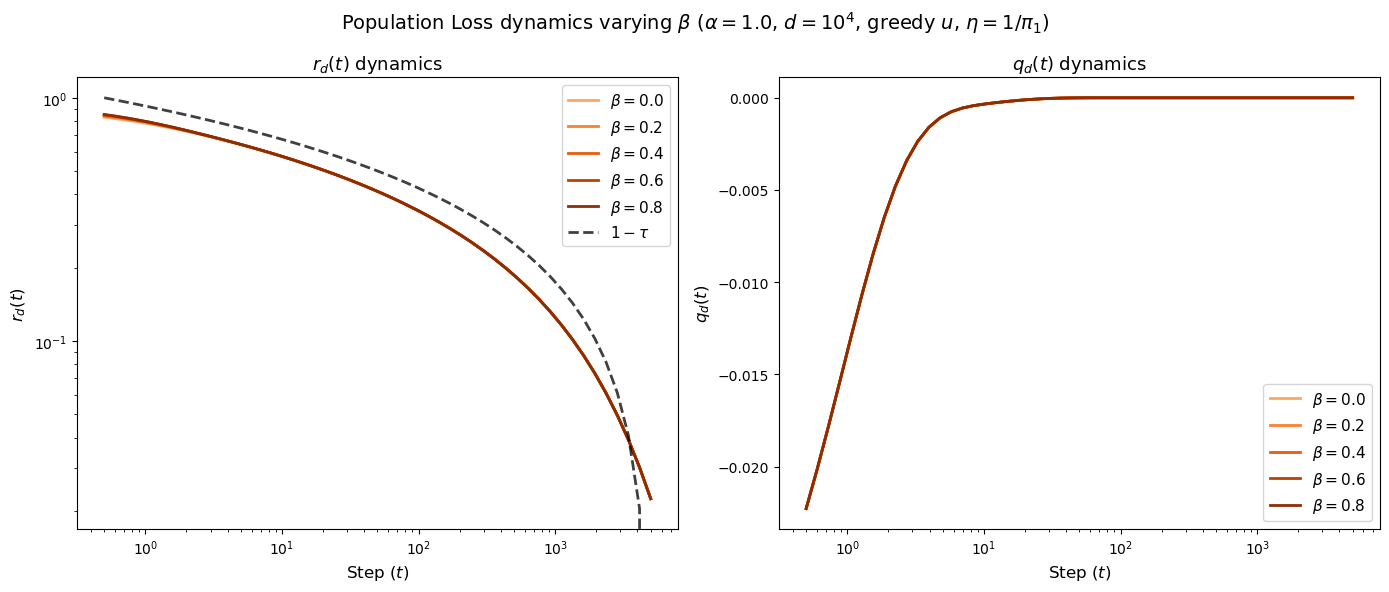

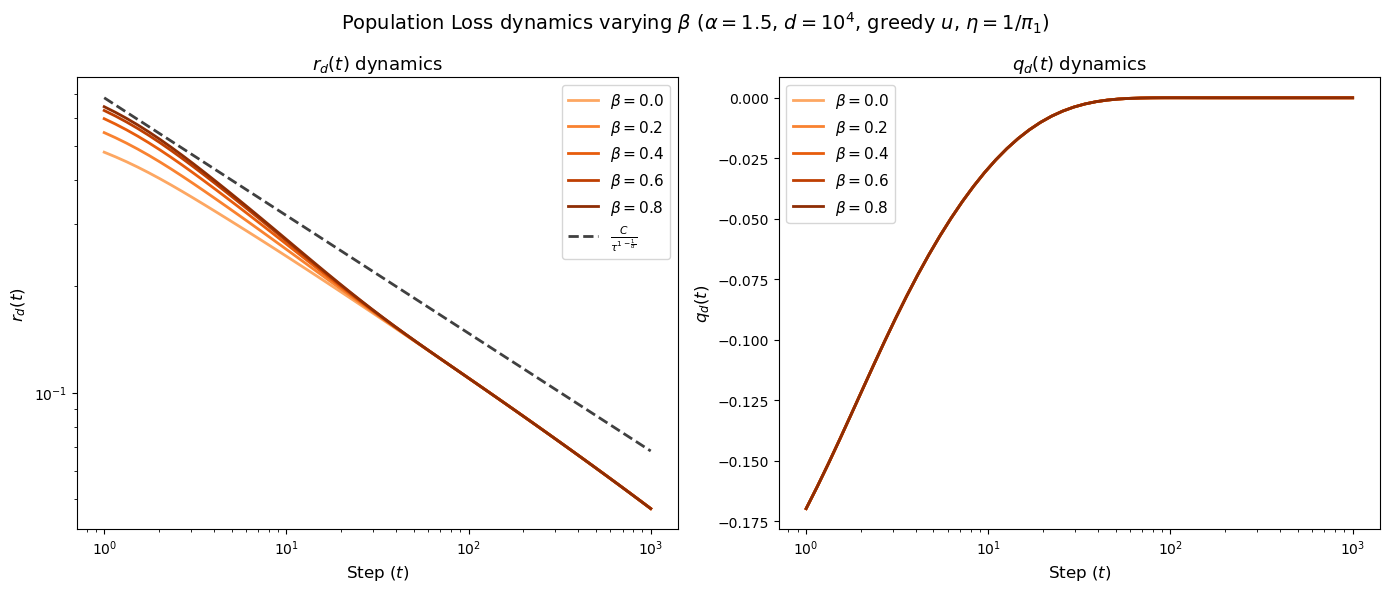

In [ ]:
from POPplots import plot_d_fixed

#----Plot--------
plot_d_fixed(filepath)

## $|q(t)|$ dynamics across multiple vocabulary sizes
A(t) governs the dynamics of the perturbation term. Analytically, $ A(t)/\pi_1 = \sum_k u_k k^{-\alpha} (1- k^{-\alpha})^{2t}$ does not depend from the voc size when $\eta = 1/\pi_1$(showed below). In this context the dependence from d is totally in $\pi_1$
The curves for $A(t)$ starts from $A(0) = -\pi_1$ (checked analytically).
We define an empirical threshold value for A(t), below which we can considered its dynamics as stopped

In [6]:
from POPplots import plot_perturb_evo

alphas = [0.5, 1.0, 1.5]
ds = [int(1e3), int(1e4), int(1e5), int(1e6)]
method = 'greedy'

#----Evo and data creation----
filepath = evoloss_beta_fixed(alphas, ds, beta=0.4, n_passes = 10, t_start=1e-5, t_stop=1e5, nice_plots=False, method=method)



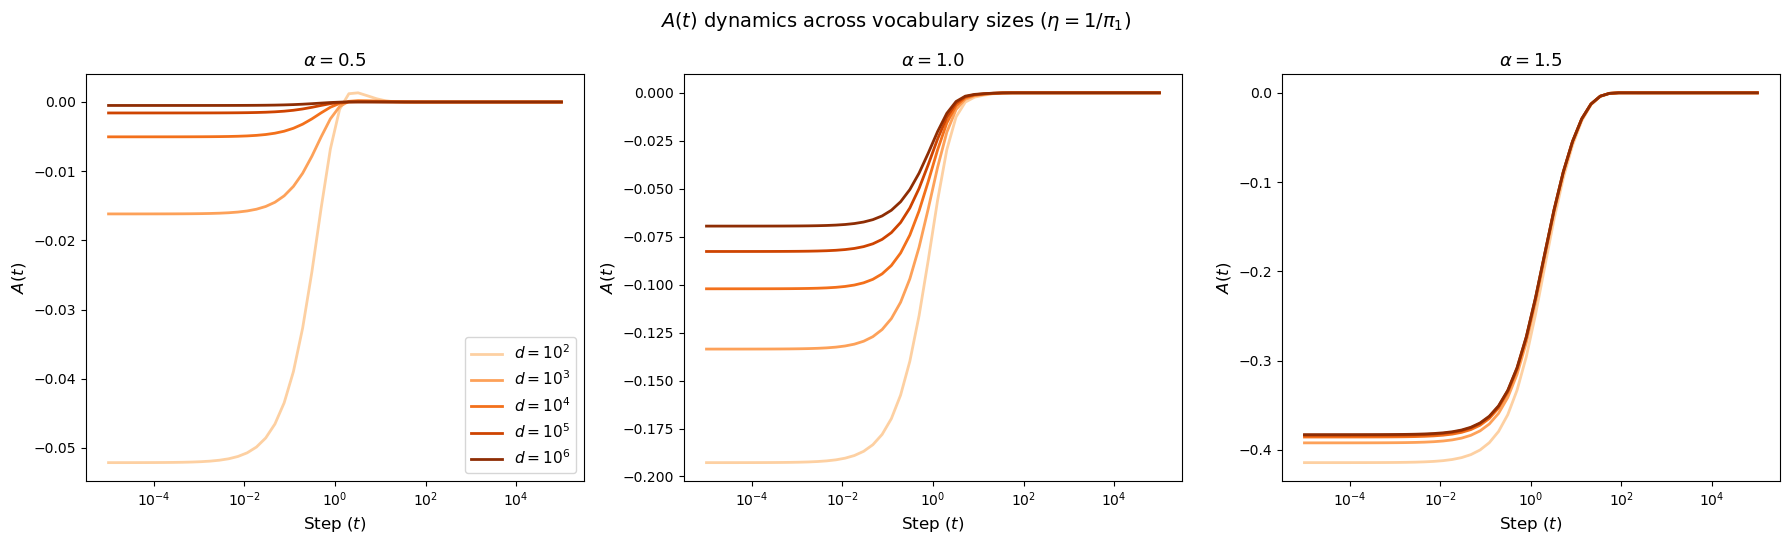

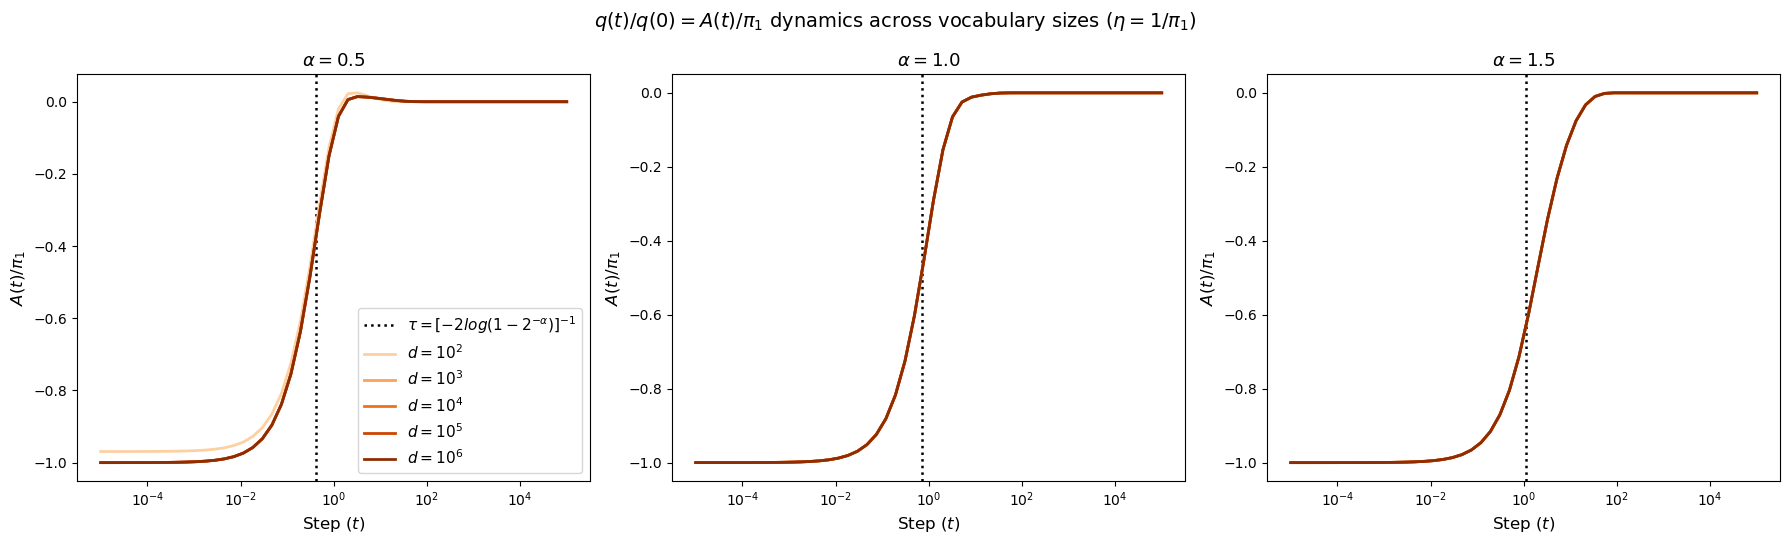

In [5]:

filepath = '/home/lucadriu/Desktop/uni/Tesi/Final/experiments/all/population/data/evo_fixed_beta_greedy.pkl'
plot_perturb_evo(filepath)

## 

/tmp/ipykernel_19568/4045406702.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Oranges')


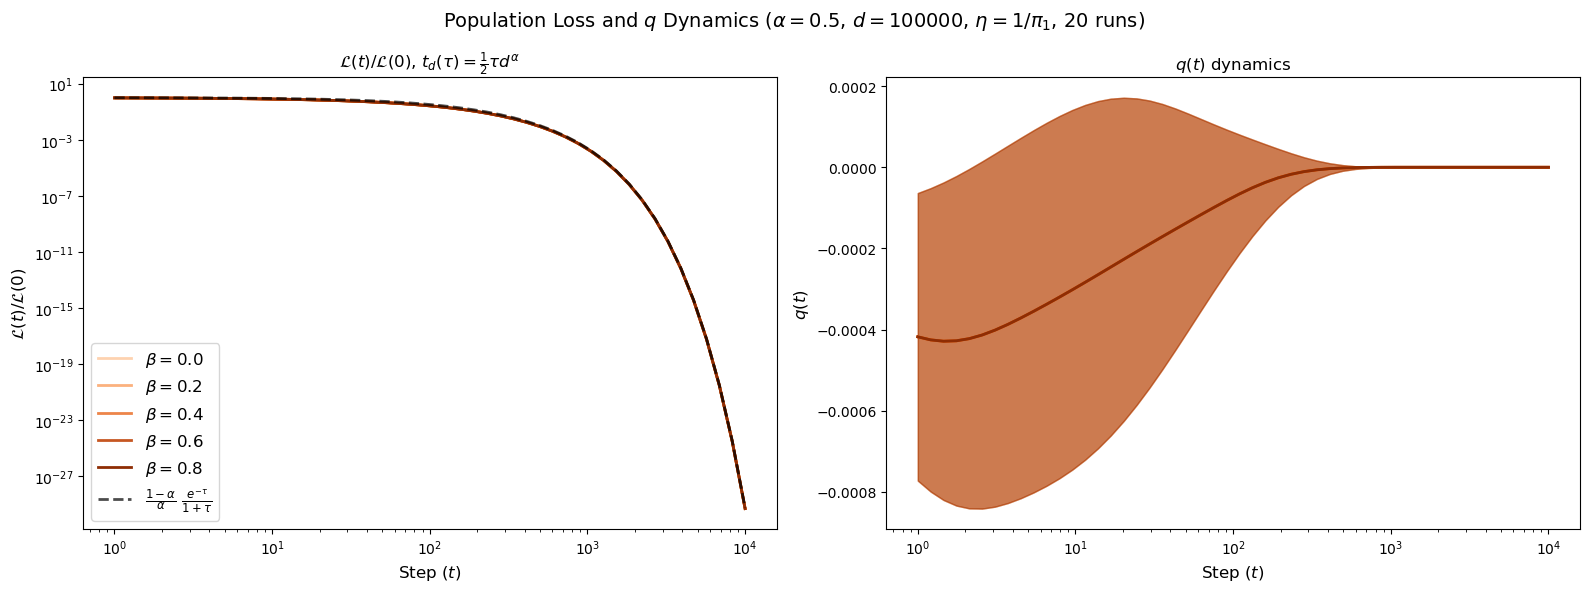

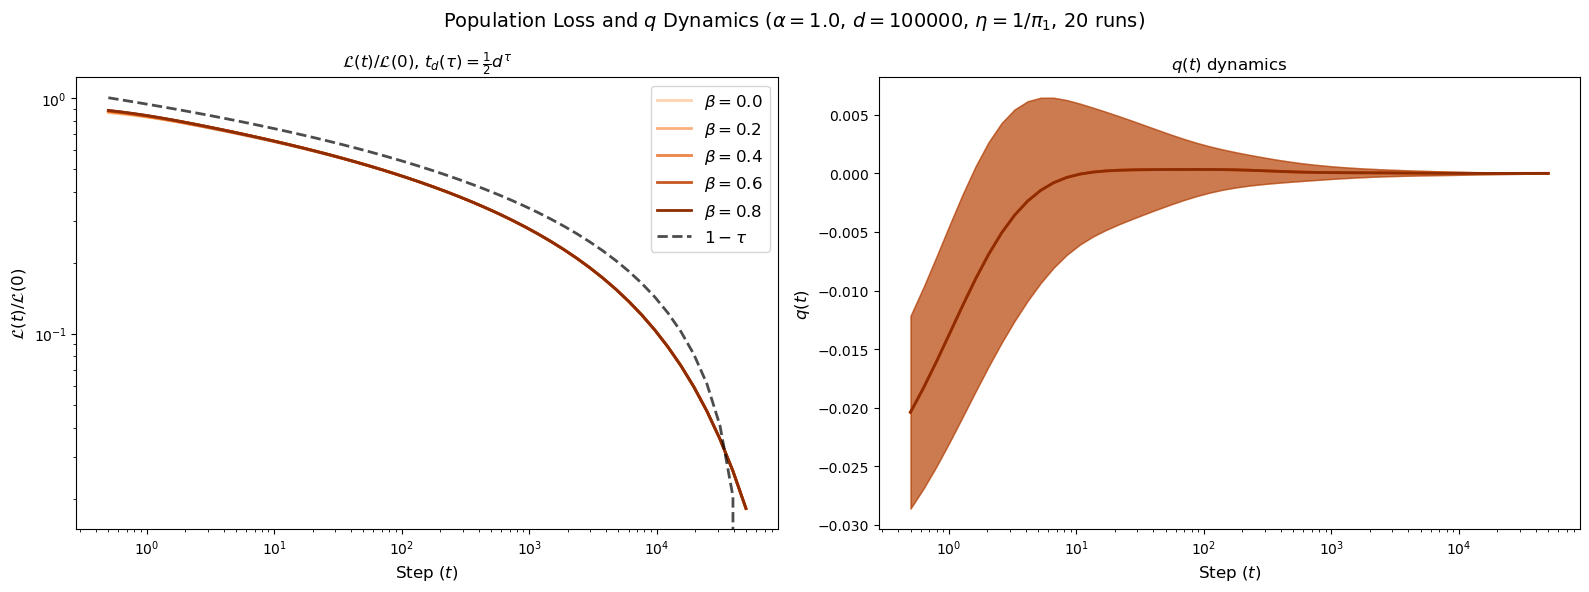

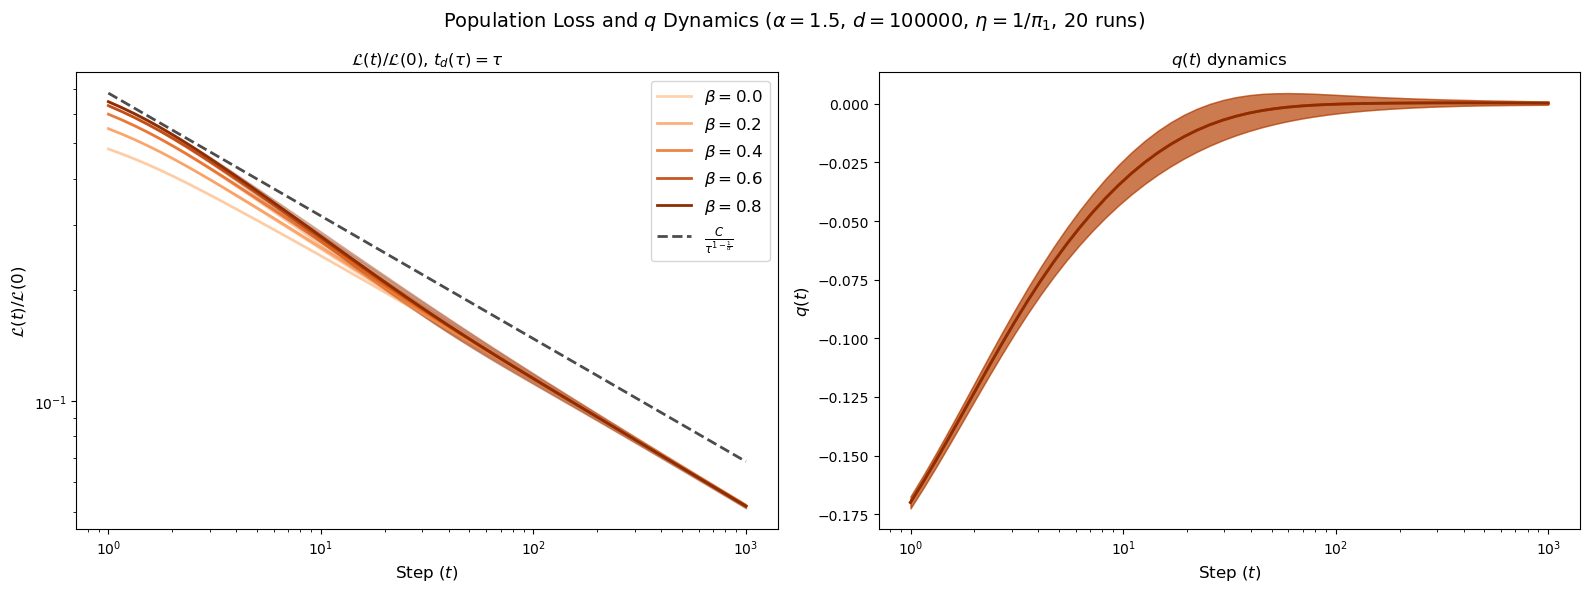

In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from POPloss import evo_loss_multi, token_freq

#------------------------------
d = int(1e5)
n_runs = 20
n_passes = 3

betas = [0.00, 0.2, 0.40, 0.6, 0.8]
alphas = [0.5, 1.0, 1.5]
num_betas = len(betas)

cmap = cm.get_cmap('Oranges')
color_intensities = np.linspace(0.4, 0.95, num_betas)
trasp = np.linspace(0.50, 1.0, num_betas)

for alpha in alphas:
    if alpha < 1.0:
        t_start, t_stop = 1 , 1e4
    if alpha == 1.0:
        t_start, t_stop = 0.5 , 5e4
    if alpha > 1.0:
        t_start, t_stop = 1 , 1e3

    pi = token_freq(d, alpha)
    eta = 1/pi[0]

    t_steps, mean_dyn, std_dyn, mean_dyn_q, std_dyn_q, refline = evo_loss_multi(d, alpha, pi, betas, eta,
                                                                               t_start, t_stop, n_runs, n_passes)

    fig, (ax_L, ax_q) = plt.subplots(1, 2, figsize=(16, 6))

    for i, beta in enumerate(betas):

        ax_L.plot(t_steps, mean_dyn[i], linestyle='-', color=cmap(color_intensities[i]),
                  alpha=trasp[i], linewidth=2.0, label=f'$\\beta = {beta}$')

        ax_L.fill_between(t_steps, mean_dyn[i] - std_dyn[i], mean_dyn[i] + std_dyn[i],
                          color=cmap(color_intensities[i]), alpha=trasp[i] * 0.3)

        ax_q.plot(t_steps, mean_dyn_q[i], linestyle='-', color=cmap(color_intensities[i]),
                  alpha=trasp[i], linewidth=2.0, label=f'$\\beta = {beta}$')

        ax_q.fill_between(t_steps, mean_dyn_q[i] - std_dyn_q[i], mean_dyn_q[i] + std_dyn_q[i],
                          color=cmap(color_intensities[i]), alpha=trasp[i] * 0.3)

    if alpha < 1.0:
        ax_L.plot(t_steps, refline, linestyle='--', color='black',
                  alpha = 0.7, linewidth=2.0, label=r'$ \frac{1-\alpha}{\alpha}$ $\frac{e^{-\tau}}{1+\tau}$')
        ax_L.set_title(fr'$\mathcal{{L}}(t)/\mathcal{{L}}(0)$, $t_d(\tau) = \frac{{1}}{{2}}\tau d^{{\alpha}}$')

    if alpha == 1.0:
        ax_L.plot(t_steps, refline, linestyle='--', color='black',
                  alpha = 0.7, linewidth=2.0, label=r'$ 1 - \tau$')
        ax_L.set_title(fr'$\mathcal{{L}}(t)/\mathcal{{L}}(0)$, $t_d(\tau) = \frac{{1}}{{2}}d^{{\tau}}$')

    if alpha > 1.0:
        ax_L.plot(t_steps, refline, linestyle='--', color='black',
                  alpha = 0.7, linewidth=2.0, label=r'$ \frac{C}{\tau^{1-\frac{1}{\alpha}}}$')
        ax_L.set_title(fr'$\mathcal{{L}}(t)/\mathcal{{L}}(0)$, $t_d(\tau) = \tau$')

    ax_L.set_xlabel(r'Step ($t$)', fontsize=12)
    ax_L.set_ylabel(r'$\mathcal{L}(t) / \mathcal{L}(0)$', fontsize=12)
    ax_L.set_xscale('log')
    ax_L.set_yscale('log')
    ax_L.legend(fontsize=12)

    ax_q.set_title(r'$q(t)$ dynamics')
    ax_q.set_xlabel(r'Step ($t$)', fontsize=12)
    ax_q.set_ylabel(r'$q(t)$', fontsize=12)
    ax_q.set_xscale('log')
    #ax_q.set_yscale('log')
    #ax_q.legend(fontsize=12)

    fig.suptitle(fr'Population Loss and $q$ Dynamics ($\alpha={alpha}$, $d={d}$, $\eta = 1/\pi_1$, {n_runs} runs) ', fontsize=14)
    fig.tight_layout()
    #fig.savefig(fr'/home/lucadriu/Desktop/uni/Tesi/Final/experiments/population/plots/multi/loss_and_q_{alpha}_{d}.png')
    plt.show()